# 2 Data

This notebook is designed to describe the data loaded in notebook 01_loading.ipynb

## 2.1 Imports

In [1]:
from pathlib import Path
import os

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

import utilities as u

pd.options.display.max_rows = 1000
print(Path('..').absolute())

def get_methods(obj):
    return [method_name for method_name in dir(obj)
            if not callable(getattr(obj, method_name)) and not method_name.startswith('_') and 'dict' not in method_name]

c:\Users\User\Askar\Thesis\..


## 2.2 Check the initial file structure

In [2]:
all_entries = pd.read_csv('all_scpdb_entries.txt', header=None)
all_entries = sorted(all_entries.iloc[:, 0].to_list())

u.check_file_structure(Path('.'),
                       {
                        "all_scpdb_entries.txt": None,
                        "excluded_scpdb_entries.txt": None,
                         "01_loading.ipynb": None,
                         "02_data.ipynb": None,
                         "SIFTS": {"pdb_chain_enzyme.csv": None,
                                   "pdb_chain_uniprot.csv": None,
                                   "scop.csv": None,
                                   "scop_names.csv": None,},
                         "Files": {"SCOPe": {"2_08.csv": None},
                                   "scPDB": {entry: {'protein.mol2': None, 'site.mol2': None} for entry in all_entries}},
                        });

File Structure Check Report:
--------------------------
The expected structure:

├── all_scpdb_entries.txt
├── excluded_scpdb_entries.txt
├── 01_loading.ipynb
├── 02_data.ipynb
├── SIFTS
│   ├── pdb_chain_enzyme.csv
│   ├── pdb_chain_uniprot.csv
│   ├── scop.csv
│   └── scop_names.csv
└── Files
    ├── SCOPe
    │   └── 2_08.csv
    └── scPDB
        ├── 10mh_1
        │   ├── protein.mol2
        │   └── site.mol2
        ├── 11bg_2
        │   ├── protein.mol2
        │   └── site.mol2
        ├── 12gs_1
        │   ├── protein.mol2
        │   └── site.mol2
        ├── 13gs_1
        │   ├── protein.mol2
        │   └── site.mol2
        ├── 17gs_1
        │   ├── protein.mol2
        │   └── site.mol2
        ├── 19gs_1
        │   ├── protein.mol2
        │   └── site.mol2
        ├── 1a26_1
        │   ├── protein.mol2
        │   └── site.mol2
        ├── 1a27_1
        │   ├── protein.mol2
        │   └── site.mol2
        ├── 1a29_1
        │   ├── protein.mol2
        │   └──

## 2.3 SCPDB Class

This Class encompasses managing and preprocessing of scPDB entries and allows to extract different properties

In [3]:
sample = u.SCPDB('9gss')

    SCPDB.folder

can be used to get paths to the folder and files by calling the methods, and to read the files by calling .content

In [4]:
print(sample.folder)

print(sample.folder.html_json.content)

print(sample.folder.ligand_mol2)

print(sample.folder.ligand_mol2.content[:1000])


Files/scPDB\9gss_1
{'scPDB ID': '9gss_1', 'PDB ID': '9gss', 'PDB URL': 'http://www.rcsb.org/pdb/explore/explore.do?structureId=9gss', 'Resolution': '1.970', 'Method': 'X-ray', 'Deposition Date': '1997-08-14', 'Name': 'Glutathione S-transferase P', 'Uniprot ID': 'GSTP1_HUMAN', 'AC': 'P09211', 'Organism': 'Homo sapiens', 'Reign': 'Eukaryota', 'TaxID': '9606', 'EC': '2.5.1.18', 'Percentage of Residues within binding site per Chain': 'A = 93 / B = 7', 'Chains': 'A,B', 'Number of Chains': 2, 'B-Factor of Binding Site': '19.055', 'Number of Residues in Binding Site': '29', 'Standard Amino Acids in Binding Site': '27', 'Non Standard Amino Acids in Binding Site': '0', 'Water Molecules in Binding Site': '2', 'Cofactors in Binding Site': '', 'Metals in Binding Site': '', 'Cavity Ligandability': '0.638', 'Cavity Volume (A^3)': '418.500', 'Cavity % Hydrophobic': '44.35', 'Cavity % Polar': '55.65', 'Ligand Het Code': 'GTX', 'Ligand Formula': 'C16H28N3O6S', 'Ligand Molecular Weight': '390.475', 'Lig


    SCPDB.html.protein
    SCPDB.html.protein.Get_Chain(chain_name)
    SCPDB.html.ligand

By html.protein and html.ligand one can get attributes fetched from scPDB web page. All attributes can be seen by calling .dict

Using .Get_Chain one can reach an html_chain entry

In [5]:
print('SCPDB.html.ligand properties:')
for prop in get_methods(sample.html.ligand):
    print('\t.', prop.ljust(30), getattr(sample.html.ligand, prop), sep='')

print('\nSCPDB.html.protein properties:')
for prop in get_methods(sample.html.protein):
    print('\t.', prop.ljust(30), getattr(sample.html.protein, prop), sep='')

print('\nSCPDB.html.protein.Get_Chain("A") properties:')
for prop in get_methods(sample.html.protein.Get_Chain('A')):
    print('\t.', prop.ljust(30), getattr(sample.html.protein.Get_Chain('A'), prop), sep='')

SCPDB.html.ligand properties:
	.Anionic_Atoms                 2
	.Aromatic_Rings                0
	.Buried_Surface_Area           52.51
	.Cationic_Atoms                1
	.DrugBank_ID                   -
	.Formula                       C16H28N3O6S
	.H_Bond_Acceptors              7
	.H_Bond_Donors                 3
	.Het_Code                      GTX
	.Mass_Center_X                 10.1803
	.Mass_Center_Y                 6.72642
	.Mass_Center_Z                 27.3243
	.Molecular_Weight              390.475
	.Polar_Surface_Area            191.42
	.Rings                         0
	.Rotatable_Bonds               15
	.Rule_of_Five_Violation        0

SCPDB.html.protein properties:
	.B_Factor_of_Binding_Site      19.055
	.Cavity_Ligandability          0.638
	.Cavity_Percent_Hydrophobic    44.35
	.Cavity_Percent_Polar          55.65
	.Cavity_Volume                 418.500
	.Chain_Names                   A,B
	.Chain_Site_Distribution       93/7
	.Chains                        [<HTML Protein C


    SCPDB.rcsb
    SCPDB.rcsb.Dominant_Chain
    SCPDB.rcsb.Main_Ligand

By rcsb one can get attributes fetched from RCSB API. SCPDB.rcsb refers to rcsb entry; SCPDB.rcsb.Chains or SCPDB.rcsb.Dominant_Chain refer to rcsb polymer entity;
SCPDB.rcsb.Main_Ligand refers to the ligand registered in scPDB


In [6]:

print('SCPDB.rcsb properties:')
for prop in get_methods(sample.rcsb):
    print('\t.', prop.ljust(50), getattr(sample.rcsb, prop), sep='')

print('\nSCPDB.rcsb.Dominant_Chain properties:')
for prop in get_methods(sample.rcsb.Dominant_Chain):
    print('\t.', prop.ljust(50), getattr(sample.rcsb.Dominant_Chain, prop), sep='')

print('\nSCPDB.rcsb.Main_Ligand properties:')
for prop in get_methods(sample.rcsb.Main_Ligand):
    print('\t.', prop.ljust(50), getattr(sample.rcsb.Main_Ligand, prop), sep='')

SCPDB.rcsb properties:
	.Assembly_Count                                    None
	.Branched_Entities                                 []
	.Branched_Entity_Count                             None
	.Chain_Configuration                               2
	.Chain_Names                                       ['A', 'B']
	.Cis_Peptide_Count                                 None
	.Crystal_Grow_Method                               None
	.Crystal_Grow_PH                                   None
	.Deposited_Atom_Count                              None
	.Deposited_Hydrogen_Atom_Count                     None
	.Deposited_Modeled_Polymer_Monomer_Count           None
	.Deposited_Nonpolymer_Entity_Instance_Count        None
	.Deposited_Polymer_Entity_Instance_Count           None
	.Deposited_Polymer_Monomer_Count                   None
	.Deposited_Solvent_Atom_Count                      None
	.Deposited_Unmodeled_Polymer_Monomer_Count         None
	.Detector                                          None
	.Diffa


    SCPDB.mol2.protein
        SCPDB.mol2.protein.Get_Chain
    SCPDB.mol2.site
        SCPDB.mol2.site.Get_Chain
    SCPDB.mol2.ligand

By SCPDB.mol2 one can reach the descriptors computed from mol2 files. 

mol2.protein refers to protein.mol2 file and can also be computed for separate chains by calling Get_Chain

mol2.site refers to site.mol2 file and can also be computed for separate chains by calling Get_Chain

mol2.ligand refers to ligand.mol2 file

In [15]:
def make_compact(obj):

    if isinstance(obj, pd.DataFrame):
        return f'pd.DataFrame ({len(obj)} rows)'
    elif isinstance(obj, str) and 'TRIPOS' in obj:
        return 'Raw Mol2'
    elif isinstance(obj, str) and len(obj) > 1000:
        return obj[:500] + ' <...> ' + obj[-500:]
    
    return obj

print('SCPDB.mol2.protein properties:')
for prop in get_methods(sample.mol2.protein):
    print('\t.', prop.ljust(50), make_compact(getattr(sample.mol2.protein, prop)), sep='')

print('SCPDB.mol2.ligand properties:')
for prop in get_methods(sample.mol2.ligand):
    print('\t.', prop.ljust(50), make_compact(getattr(sample.mol2.ligand, prop)), sep='')

print('SCPDB.mol2.site properties:')
for prop in get_methods(sample.mol2.site):
    print('\t.', prop.ljust(50), make_compact(getattr(sample.mol2.site, prop)), sep='')

print('SCPDB.mol2.site.Get_Chain("A") properties:')
for prop in get_methods(sample.mol2.site.Get_Chain("A")):
    print('\t.', prop.ljust(50), make_compact(getattr(sample.mol2.site.Get_Chain("A"), prop)), sep='')

SCPDB.mol2.protein properties:
	.Atom_Block                                        ['     1 C           29.3680     3.1450    36.9060 C.2          1 PRO2     0.0000', '     2 O           28.9810     4.2970    36.9350 O.2          1 PRO2     0.0000', '     3 CA          30.5850     2.7540    37.7460 C.3          1 PRO2     0.0000', '     4 N           30.5310     3.6040    38.9520 N.pl3        1 PRO2     0.0000', '     5 CD          30.0200     2.7930    40.0880 C.3          1 PRO2     0.0000', '     6 CG          29.5860     1.4680    39.4360 C.3          1 PRO2     0.0000', '     7 CB          30.4730     1.2980    38.2250 C.3          1 PRO2     0.0000', '     8 HA          31.4344     2.9018    37.2394 H            1 PRO2     0.0000', '     9 HD2         29.2427     3.2449    40.5257 H            1 PRO2     0.0000', '    10 HD3         30.7393     2.6369    40.7649 H            1 PRO2     0.0000', '    11 HG2         28.6256     1.5129    39.1611 H            1 PRO2     0.0000', '  

## 2.4 Creating an Aggregated Dataset

The whole process might take 12-24 hours. The result is a CSV file with combined properties of all the entries.

In [20]:
dataset_path = os.path.join('Files', 'database_v0.csv')

if not os.path.isfile(dataset_path):

    u.aggregate_dictoinaries(
        start_from=0,
        df_version=0,
        save_fasta=False,
        save_residues=False,
        save_atoms=False,
        save_json=False,
        from_compiled=False
    )

df_complete = pd.read_csv('Files/database_v0.csv', sep='@', usecols=list(range(2000)))

## 2.5 Tables

Specific function from utilities (u.describe_database) creates a number of tables from the dataset and returns a dictionary of dataframes

By default, the following tables are generated:

- 'Basic IDs'
- 'Completeness'
- 'NFiles'
- 'ChemProtCon'
- 'ChemProtOrd'
- 'ChemProtCat'
- 'ChemLigCon'
- 'ChemLigOrd'
- 'ChemLigCat'
- 'MetCon'
- 'MetOrd'
- 'MetCat'
- 'Mol2OverCon'
- 'Mol2OverOrd'
- 'Mol2OverCat'
- 'Mol2ElemCon'
- 'Mol2ResCon'
- 'Mol2StrOrd'
- 'Mol2ElemShort'
- 'Mol2ResShort'

In [21]:
tables = u.describe_database(df_complete)

### 2.5.1 Basic IDs

statistics about identifiers

In [24]:
tables['Basic IDs']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount
0,basic,scPDB ID,17594,100 %,17594,100 %,100 %,NaN
1,basic,PDB ID,17594,100 %,16612,94.4 %,94.4 %,1w19 (4/0.0227%); 1amo (3/0.0171%); 1j3j (3/0.0171%); 1ja0 (3/0.0171%); 1ja1 (3/0.0171%); 1t9a (3/0.0171%)
2,html,Name,15920,90.5 %,3444,19.6 %,21.6 %,"Gag-Pol polyprotein (466/2.65%); Cyclin-dependent kinase 2 (274/1.56%); Dihydrofolate reductase (241/1.37%); Nitric oxide synthase, brain (193/1.1%); Beta-secretase 1 (191/1.09%); Mitogen-activated protein kinase 14 (187/1.06%)"
3,combined,UniProt,17585,99.9 %,5034,28.6 %,28.6 %,P24941 (281/1.6%); P29476 (194/1.1%); P56817 (192/1.09%); Q16539 (175/0.995%); P00918 (146/0.83%); P00734 (131/0.745%)
4,combined,EC,17252,98.1 %,1585,9.01 %,9.19 %,/ (2500/14.2%); 2.7.11.1 (766/4.35%); 2.7.7.49 (597/3.39%); 2.7.11.22 (313/1.78%); 1.5.1.3 (303/1.72%); 2.7.11.24 (286/1.63%)
5,combined,SCOPe,11979,68.1 %,776,4.41 %,6.48 %,l.1.1.1 (1273/7.24%); d.144.1.7 (1195/6.79%); b.50.1.1 (441/2.51%); c.2.1.2 (301/1.71%); a.123.1.1 (296/1.68%); d.144.1.0 (284/1.61%)
6,combined,SCOP1,2123,12.1 %,4,0.0227 %,0.188 %,Globular proteins (2073/11.8%); Membrane proteins (37/0.21%); Non-globular/Intrinsically unstructured proteins (7/0.0398%); Fibrous proteins (6/0.0341%)
7,html,Uniprot ID,15920,90.5 %,4689,26.7 %,29.5 %,CDK2_HUMAN (274/1.56%); NOS1_RAT (193/1.1%); BACE1_HUMAN (191/1.09%); MK14_HUMAN (170/0.966%); CAH2_HUMAN (137/0.779%); THRB_HUMAN (126/0.716%)
8,html,AC,15920,90.5 %,4689,26.7 %,29.5 %,P24941 (274/1.56%); P29476 (193/1.1%); P56817 (191/1.09%); Q16539 (170/0.966%); P00918 (137/0.779%); P00734 (126/0.716%)
9,html,TaxID,16009,91 %,1072,6.09 %,6.7 %,9606.0 (5406/30.7%); 83333.0 (872/4.96%); 10116.0 (568/3.23%); 10090.0 (360/2.05%); 83332.0 (358/2.03%); 559292.0 (331/1.88%)


### 2.5.2 Completeness of Materials

How many data was collected

In [25]:
tables['Completeness']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount
0,basic,Protein Mol2,17594,100 %,1,0.00568 %,0.00568 %,True (17594/100%)
1,basic,Site Mol2,17594,100 %,1,0.00568 %,0.00568 %,True (17594/100%)
2,basic,Cavity Mol2,17594,100 %,1,0.00568 %,0.00568 %,True (17594/100%)
3,basic,Interaction Mol2,17594,100 %,1,0.00568 %,0.00568 %,True (17594/100%)
4,basic,IPF txt,17594,100 %,1,0.00568 %,0.00568 %,True (17594/100%)
5,basic,HTML JSON,16033,91.1 %,1,0.00568 %,0.00624 %,True (16033/91.1%)
6,basic,HTML txt,16033,91.1 %,1,0.00568 %,0.00624 %,True (16033/91.1%)
7,basic,RCSB JSON,17539,99.7 %,1,0.00568 %,0.0057 %,True (17539/99.7%)
8,basic,RCSB identifiers,17539,99.7 %,1,0.00568 %,0.0057 %,True (17539/99.7%)
9,basic,Minimum Requirements,17594,100 %,1,0.00568 %,0.00568 %,True (17594/100%)


### 2.5.3 Number of RCSB Fetched Files

How many RCSB file types were fetched

In [27]:
tables['NFiles']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount,Min,Max,Mean,Median,Range,Std
0,basic,RCSB Entities,17594,100 %,23,0.131 %,0.131 %,3 (5359/30.5%); 4 (4098/23.3%); 2 (3843/21.8%); 5 (2259/12.8%); 6 (1112/6.32%); 7 (402/2.28%),0.0,23.0,3.725588,3.0,23.0,1.688953
1,basic,RCSB Assemblies,17594,100 %,22,0.125 %,0.125 %,1 (11974/68.1%); 2 (3814/21.7%); 3 (876/4.98%); 4 (531/3.02%); 6 (135/0.767%); 5 (98/0.557%),0.0,32.0,1.525577,1.0,32.0,1.192423
2,basic,RCSB Poly Entities,17594,100 %,13,0.0739 %,0.0739 %,1 (15169/86.2%); 2 (1728/9.82%); 3 (455/2.59%); 4 (124/0.705%); 0 (55/0.313%); 5 (21/0.119%),0.0,14.0,1.193418,1.0,14.0,0.665202
3,basic,RCSB Non Poly,17594,100 %,14,0.0796 %,0.0796 %,2 (5572/31.7%); 1 (4463/25.4%); 3 (3982/22.6%); 4 (1940/11%); 5 (939/5.34%); 6 (318/1.81%),0.0,15.0,2.506764,2.0,15.0,1.420504
4,basic,RCSB Branched,17594,100 %,8,0.0455 %,0.0455 %,0 (17283/98.2%); 1 (235/1.34%); 2 (47/0.267%); 3 (13/0.0739%); 4 (11/0.0625%); 5 (2/0.0114%),0.0,9.0,0.025406,0.0,9.0,0.234039
5,rcsb rcsb_entry_info,entity_count,17539,99.7 %,23,0.131 %,0.131 %,4.0 (5203/29.6%); 5.0 (4050/23%); 3.0 (3827/21.8%); 6.0 (2219/12.6%); 7.0 (1106/6.29%); 8.0 (394/2.24%),2.0,24.0,4.695194,4.0,22.0,1.703546
6,rcsb rcsb_entry_info,assembly_count,17539,99.7 %,21,0.119 %,0.12 %,1.0 (11974/68.1%); 2.0 (3814/21.7%); 3.0 (876/4.98%); 4.0 (531/3.02%); 6.0 (135/0.767%); 5.0 (98/0.557%),1.0,32.0,1.530361,1.0,31.0,1.191222
7,rcsb rcsb_entry_info,branched_entity_count,17539,99.7 %,8,0.0455 %,0.0456 %,0.0 (17223/97.9%); 1.0 (236/1.34%); 2.0 (51/0.29%); 3.0 (13/0.0739%); 4.0 (11/0.0625%); 5.0 (2/0.0114%),0.0,9.0,0.026056,0.0,9.0,0.238439
8,rcsb rcsb_entry_info,cis_peptide_count,17539,99.7 %,45,0.256 %,0.257 %,0.0 (8454/48.1%); 2.0 (2786/15.8%); 1.0 (2719/15.5%); 4.0 (1157/6.58%); 3.0 (713/4.05%); 6.0 (467/2.65%),0.0,94.0,1.785963,1.0,94.0,3.483016
9,rcsb rcsb_entry_info,nonpolymer_entity_count,17539,99.7 %,14,0.0796 %,0.0798 %,2.0 (5572/31.7%); 1.0 (4463/25.4%); 3.0 (3982/22.6%); 4.0 (1940/11%); 5.0 (939/5.34%); 6.0 (318/1.81%),0.0,15.0,2.514625,2.0,15.0,1.415765


### 2.5.4 Protein Properties (continuous)

In [28]:
tables['ChemProtCon']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,Min,Max,Mean,Median,Range,Std
0,html,B-Factor of Binding Site,16033,91.1 %,13568,77.1 %,84.6 %,0.000,99.999,30.409264,27.055,99.999,16.579487
1,html,Cavity Ligandability,16033,91.1 %,1959,11.1 %,12.2 %,0.000,2.444,0.856625,0.872,2.444,0.431680
2,html,Cavity Volume (A^3),16033,91.1 %,725,4.12 %,4.52 %,236.250,2770.875,792.661682,675.000,2534.625,459.304095
3,html,Cavity % Hydrophobic,16033,91.1 %,3993,22.7 %,24.9 %,18.940,93.810,49.058871,47.780,74.870,10.283428
4,html,Cavity % Polar,16033,91.1 %,3993,22.7 %,24.9 %,6.190,81.060,50.941164,52.220,74.870,10.283422
5,rcsb rcsb_entry_info,molecular_weight,17539,99.7 %,9530,54.2 %,54.3 %,7.340,1646.370,88.675768,60.840,1639.030,89.531747
6,rcsb refine_hist,number_atoms_solvent,17418,99 %,1494,8.49 %,8.58 %,0.000,6111.000,321.780572,217.000,6111.000,388.313718
7,rcsb refine_hist,number_atoms_total,17418,99 %,8515,48.4 %,48.9 %,0.000,92645.000,6241.029223,4326.000,92645.000,6128.781807
8,rcsb refine_hist,pdbx_number_atoms_protein,17418,99 %,7374,41.9 %,42.3 %,0.000,91576.000,5799.991905,3988.000,91576.000,5834.590305
9,rcsb rcsb_entry_info,polymer_molecular_weight_maximum,17539,99.7 %,4407,25 %,25.1 %,2.940,171.000,39.052016,36.180,168.060,18.228479


### 2.5.5 Protein Properties (ordinal)

In [29]:
tables['ChemProtOrd']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount,Min,Max,Mean,Median,Range,Std
0,html,Number of Chains,16033,91.1 %,6,0.0341 %,0.0374 %,1.0 (11739/66.7%); 2.0 (4051/23%); 3.0 (207/1.18%); 4.0 (32/0.182%); 5.0 (3/0.0171%); 6.0 (1/0.00568%),1.0,6.0,1.285536,1.0,5.0,0.495288
1,html,Number of Residues in Binding Site,16033,91.1 %,79,0.449 %,0.493 %,31.0 (738/4.19%); 33.0 (731/4.15%); 29.0 (701/3.98%); 30.0 (693/3.94%); 35.0 (685/3.89%); 32.0 (658/3.74%),8.0,90.0,36.450009,35.0,82.0,10.779725
2,html,Standard Amino Acids in Binding Site,16033,91.1 %,72,0.409 %,0.449 %,33.0 (759/4.31%); 28.0 (748/4.25%); 32.0 (743/4.22%); 27.0 (742/4.22%); 31.0 (738/4.19%); 30.0 (734/4.17%),7.0,79.0,34.488929,33.0,72.0,9.946025
3,html,Non Standard Amino Acids in Binding Site,16033,91.1 %,10,0.0568 %,0.0624 %,0.0 (10025/57%); 1.0 (4554/25.9%); 2.0 (1174/6.67%); 3.0 (211/1.2%); 4.0 (47/0.267%); 5.0 (11/0.0625%),0.0,9.0,0.489927,0.0,9.0,0.744014
4,html,Water Molecules in Binding Site,16033,91.1 %,13,0.0739 %,0.0811 %,0.0 (5834/33.2%); 1.0 (4120/23.4%); 2.0 (2638/15%); 3.0 (1557/8.85%); 4.0 (876/4.98%); 5.0 (496/2.82%),0.0,12.0,1.471153,1.0,12.0,1.685564
5,rcsb,Number of Chains,17594,100 %,28,0.159 %,0.159 %,2 (6654/37.8%); 1 (6500/36.9%); 4 (2313/13.1%); 3 (792/4.5%); 6 (461/2.62%); 8 (313/1.78%),0.0,36.0,2.413380,2.0,36.0,2.285839
6,rcsb,Number of Different Chains,17594,100 %,13,0.0739 %,0.0739 %,1 (15419/87.6%); 2 (1616/9.18%); 3 (333/1.89%); 4 (113/0.642%); 0 (55/0.313%); 5 (16/0.0909%),0.0,14.0,1.170172,1.0,14.0,0.637705
7,rcsb rcsb_entry_info,disulfide_bond_count,17539,99.7 %,37,0.21 %,0.211 %,0.0 (15176/86.3%); 1.0 (539/3.06%); 2.0 (441/2.51%); 4.0 (321/1.82%); 3.0 (296/1.68%); 6.0 (190/1.08%),0.0,80.0,0.708535,0.0,80.0,3.059005
8,rcsb rcsb_entry_info,inter_mol_metalic_bond_count,17539,99.7 %,131,0.745 %,0.747 %,0.0 (11000/62.5%); 6.0 (849/4.83%); 12.0 (563/3.2%); 4.0 (521/2.96%); 8.0 (422/2.4%); 5.0 (393/2.23%),0.0,286.0,5.737670,0.0,286.0,13.767567
9,rcsb_prot entity_poly,rcsb_non_std_monomer_count,17538,99.7 %,7,0.0398 %,0.0399 %,0.0 (15700/89.2%); 1.0 (1656/9.41%); 2.0 (164/0.932%); 5.0 (8/0.0455%); 4.0 (6/0.0341%); 3.0 (3/0.0171%),0.0,6.0,0.117630,0.0,6.0,0.372114


### 2.5.6 Protein Properties (categorical)

In [30]:
tables['ChemProtCat']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount
0,html,Metals in Binding Site,3323,18.9 %,84,0.477 %,2.53 %,MG (1280/7.28%); ZN (731/4.15%); MG MG (227/1.29%); CA (175/0.995%); CL (157/0.892%); MN (137/0.779%); MN MN (91/0.517%); FE (63/0.358%); FE2 (58/0.33%); ZN ZN (56/0.318%); MG MG MG (53/0.301%); ZN MG (38/0.216%); CL MG (24/0.136%); CA CA (23/0.131%); IOD (17/0.0966%); CA CA CA (16/0.0909%); K (13/0.0739%); NA NA (10/0.0568%); CL CL (7/0.0398%); MG NA (7/0.0398%); CL ZN (7/0.0398%)
1,html,Cofactors in Binding Site,1389,7.89 %,45,0.256 %,3.24 %,NAP (326/1.85%); FAD (274/1.56%); NDP (185/1.05%); NAD (126/0.716%); H4B (80/0.455%); FMN (67/0.381%); ATP (51/0.29%); ADP (42/0.239%); UMP (41/0.233%); COA (34/0.193%); GDP (24/0.136%); NAI (18/0.102%); GTP (18/0.102%); AMP (15/0.0853%); FMN NAP (13/0.0739%); ANP (13/0.0739%); CAA (7/0.0398%); ACP (7/0.0398%); ACO (6/0.0341%); TPP (4/0.0227%); ATP ATP (4/0.0227%)
2,html,SCOPe Chain Classes,12122,68.9 %,2720,15.5 %,22.4 %,A d.144.1.7 (921/5.23%); A b.50.1.1 / B b.50.1.1 (384/2.18%); A d.174.1.1 / B d.174.1.1 (228/1.3%); A d.144.1.0 (188/1.07%); A d.144.1.7 / B d.144.1.7 (160/0.909%); A b.50.1.2 (153/0.87%); A a.123.1.1 (148/0.841%); A b.74.1.1 (134/0.762%); A c.1.7.1 (128/0.728%); A c.71.1.1 (125/0.71%); A d.122.1.1 (107/0.608%); A a.123.1.1 / B a.123.1.1 (105/0.597%); A d.144.1.7 / A l.1.1.1 (89/0.506%); A c.2.1.2 / B c.2.1.2 / C c.2.1.2 / D c.2.1.2 (85/0.483%); A c.2.1.2 (84/0.477%); A c.2.1.2 / B c.2.1.2 (76/0.432%); A c.90.1.1 / B c.90.1.1 (75/0.426%); A a.104.1.1 (67/0.381%); A c.55.3.2 / B c.55.3.2 (64/0.364%); A b.50.1.2 / B b.50.1.2 (57/0.324%); A d.144.1.0 / A l.1.1.1 (57/0.324%)
3,html,Chain Site Distribution,16033,91.1 %,253,1.44 %,1.58 %,100 (11649/66.2%); 97/3 (373/2.12%); 96/4 (266/1.51%); 98/2 (238/1.35%); 51/49 (181/1.03%); 94/6 (161/0.915%); 52/48 (155/0.881%); 95/5 (137/0.779%); 92/8 (137/0.779%); 93/7 (134/0.762%); 91/9 (121/0.688%); 89/11 (120/0.682%); 88/12 (106/0.602%); 50/50 (97/0.551%); 90/10 (96/0.546%); 100.0 (90/0.512%); 53/47 (75/0.426%); 86/14 (70/0.398%); 85/15 (69/0.392%); 62/38 (68/0.386%); 87/13 (67/0.381%)
4,rcsb,Chain Configuration,17539,99.7 %,100,0.568 %,0.57 %,1 (5647/32.1%); 2 (5045/28.7%); 4 (1552/8.82%); 1+1 (915/5.2%); 1 (853/4.85%); 2 (694/3.94%); 3 (456/2.59%); 2+2 (434/2.47%); 6 (286/1.63%); 4 (234/1.33%); 1+1+1 (209/1.19%); 8 (208/1.18%); 12 (85/0.483%); 5 (81/0.46%); 3 (68/0.386%); 1+1+1+1 (67/0.381%); 2+1 (59/0.335%); 4+4 (53/0.301%); 10 (50/0.284%); 2+2+2 (49/0.279%); 3+3 (42/0.239%)
5,rcsb_prot entity_poly,rcsb_non_std_monomers,1838,10.4 %,110,0.625 %,5.98 %,MSE (644/3.66%); PTR (130/0.739%); TPO (123/0.699%); SEP;TPO (114/0.648%); SEP (105/0.597%); CSD (88/0.5%); CSO (82/0.466%); CME (62/0.352%); ACE (56/0.318%); KCX (49/0.279%); LLP (34/0.193%); HIC (32/0.182%); CXM (30/0.171%); PCA (20/0.114%); CSX (17/0.0966%); OCS (15/0.0853%); FMT (12/0.0682%); IAS (12/0.0682%); CSS (12/0.0682%); ABA (11/0.0625%); ACE;CSD (11/0.0625%)
6,uniprot,Subcellular Locations,17482,99.4 %,616,3.5 %,3.52 %,"[] (6041/34.3%); ['Cytoplasm'] (2317/13.2%); ['Cytoplasm', 'Nucleus'] (648/3.68%); ['Host cell membrane', 'Host cytoplasm', 'Host endosome, host multivesicular body', 'Host nucleus', 'Virion', 'Virion membrane'] (588/3.34%); ['Secreted'] (506/2.88%); ['Cell membrane'] (303/1.72%); ['Nucleus'] (299/1.7%); ['Cytoplasm, cytosol'] (290/1.65%); ['Cell membrane', 'Cytoplasm'] (289/1.64%); ['Cytoplasm', 'Cytoplasm, cytoskeleton, microtubule organizing center, centrosome', 'Endosome', 'Nucleus, Cajal body'] (281/1.6%); ['Cell membrane, sarcolemma', 'Cell projection, dendritic spine'] (194/1.1%); ['Cell membrane', 'Cell projection, axon', 'Cell projection, dendrite', 'Cell surface', 'Cytoplasmic vesicle membrane', 'Early endosome', 'Endoplasmic reticulum', 'Endosome', 'Golgi apparatus, trans-Golgi network', 'Late endosome', 'Lysosome', 'Membrane raft', 'Recycling endosome'] (192/1.09%); ['Chromosome', 'Nucleus'] (176/1%); ['Secret

### 2.5.7 Ligand Properties (continuous)

In [31]:
tables['ChemLigCon']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,Min,Max,Mean,Median,Range,Std
0,html,Ligand Molecular Weight,16033,91.1 %,5578,31.7 %,34.8 %,140.055,1498.184,475.826754,440.409,1358.129,181.045186
1,html,Ligand Buried Surface Area (A^2),16033,91.1 %,4283,24.3 %,26.7 %,0.000,88.930,63.842127,64.440,88.930,10.494642
2,html,Ligand Polar Surface Area (A^2),16033,91.1 %,3909,22.2 %,24.4 %,2.000,5512.000,220.146955,184.362,5510.000,193.585687
3,rcsb rcsb_entry_info,nonpolymer_molecular_weight_maximum,17470,99.3 %,118,0.671 %,0.675 %,0.020,1.580,0.504797,0.470,1.560,0.195773
4,rcsb rcsb_entry_info,nonpolymer_molecular_weight_minimum,17470,99.3 %,104,0.591 %,0.595 %,0.020,1.580,0.192410,0.090,1.560,0.214045
5,rcsb refine_hist,pdbx_number_atoms_ligand,17418,99 %,640,3.64 %,3.67 %,0.000,3303.000,107.286141,67.000,3303.000,124.406942
6,rcsb refine_hist,pdbx_number_atoms_nucleic_acid,17418,99 %,168,0.955 %,0.965 %,0.000,6324.000,11.970605,0.000,6324.000,143.360926
7,rcsb_ligand rcsb_nonpolymer_entity,formula_weight,17277,98.2 %,800,4.55 %,4.63 %,0.069,1.581,0.458343,0.427,1.512,0.189773


### 2.5.8 Ligand Properties (ordinal)

In [32]:
tables['ChemLigOrd']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount,Min,Max,Mean,Median,Range,Std
0,html,Ligand H-Bond Acceptors,16033,91.1 %,37,0.21 %,0.231 %,4.0 (1544/8.78%); 5.0 (1361/7.74%); 22.0 (1348/7.66%); 3.0 (1180/6.71%); 6.0 (1082/6.15%); 7.0 (1080/6.14%),0.0,49.0,10.451693,8.0,49.0,6.734962
1,html,Ligand H-Bond Donors,16033,91.1 %,19,0.108 %,0.119 %,3.0 (3198/18.2%); 4.0 (2608/14.8%); 2.0 (2593/14.7%); 1.0 (2054/11.7%); 6.0 (1668/9.48%); 5.0 (1650/9.38%),0.0,21.0,3.495229,3.0,21.0,2.107069
2,html,Ligand Rings,16033,91.1 %,10,0.0568 %,0.0624 %,3.0 (6337/36%); 2.0 (2385/13.6%); 5.0 (2362/13.4%); 4.0 (2273/12.9%); 6.0 (1226/6.97%); 1.0 (916/5.21%),0.0,9.0,3.406724,3.0,9.0,1.450118
3,html,Ligand Aromatic Rings,16033,91.1 %,9,0.0512 %,0.0561 %,2.0 (6104/34.7%); 3.0 (3956/22.5%); 1.0 (2640/15%); 0.0 (2098/11.9%); 4.0 (969/5.51%); 5.0 (209/1.19%),0.0,8.0,1.996445,2.0,8.0,1.169856
4,html,Ligand Anionic Atoms,16033,91.1 %,10,0.0568 %,0.0624 %,0.0 (6062/34.5%); 2.0 (3675/20.9%); 4.0 (2546/14.5%); 1.0 (2404/13.7%); 3.0 (1225/6.96%); 5.0 (98/0.557%),0.0,10.0,1.512443,1.0,10.0,1.489856
5,html,Ligand Cationic Atoms,16033,91.1 %,5,0.0284 %,0.0312 %,0.0 (11186/63.6%); 1.0 (4196/23.8%); 2.0 (591/3.36%); 3.0 (54/0.307%); 4.0 (6/0.0341%),0.0,4.0,0.347034,0.0,4.0,0.570126
6,html,Ligand Rule of Five Violation,16033,91.1 %,5,0.0284 %,0.0312 %,0.0 (6438/36.6%); 1.0 (3947/22.4%); 2.0 (2896/16.5%); 3.0 (2725/15.5%); 4.0 (27/0.153%),0.0,4.0,1.124057,1.0,4.0,1.123329
7,html,Ligand Rotatable Bonds,16033,91.1 %,39,0.222 %,0.243 %,8.0 (1943/11%); 13.0 (1796/10.2%); 6.0 (1730/9.83%); 7.0 (1676/9.53%); 4.0 (1186/6.74%); 5.0 (1131/6.43%),0.0,45.0,7.834841,7.0,45.0,4.938751
8,rcsb_ligand rcsb_nonpolymer_entity,pdbx_number_of_molecules,17277,98.2 %,27,0.153 %,0.156 %,1.0 (8431/47.9%); 2.0 (5426/30.8%); 4.0 (1706/9.7%); 3.0 (714/4.06%); 6.0 (333/1.89%); 8.0 (256/1.46%),1.0,123.0,2.135440,2.0,122.0,2.468804


### 2.5.9 Ligand Properties (categorical)

In [33]:
tables['ChemLigCat']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount
0,html,Ligand Formula,16033,91.1 %,5698,32.4 %,35.5 %,C27H31N9O15P2 (876/4.98%); C21H26N7O14P2 (641/3.64%); C10H12N5O10P2 (597/3.39%); C10H12N5O13P3 (430/2.44%); C21H25N7O17P3 (398/2.26%); C17H19N4O9P (363/2.06%)
1,rcsb_ligand pdbx_entity_nonpoly,comp_id,17277,98.2 %,6864,39 %,39.7 %,FAD (873/4.96%); NAD (623/3.54%); ADP (604/3.43%); ATP (406/2.31%); NAP (395/2.25%); FMN (362/2.06%)
2,rcsb_ligand pdbx_entity_nonpoly,name,17277,98.2 %,6850,38.9 %,39.6 %,FLAVIN-ADENINE DINUCLEOTIDE (873/4.96%); NICOTINAMIDE-ADENINE-DINUCLEOTIDE (623/3.54%); ADENOSINE-5'-DIPHOSPHATE (604/3.43%); ADENOSINE-5'-TRIPHOSPHATE (406/2.31%); NADP NICOTINAMIDE-ADENINE-DINUCLEOTIDE PHOSPHATE (395/2.25%); FLAVIN MONONUCLEOTIDE (362/2.06%)
3,html,Ligand Het Code,16033,91.1 %,6326,36 %,39.5 %,FAD (871/4.95%); NAD (622/3.54%); ADP (595/3.38%); ATP (401/2.28%); NAP (398/2.26%); FMN (363/2.06%)
4,html,Ligand DrugBank ID,16033,91.1 %,2281,13 %,14.2 %,- (6951/39.5%); DB03147 (871/4.95%); DB00171 (401/2.28%); DB03461 (398/2.26%); DB03247 (363/2.06%); DB01752 (351/1.99%)


### 2.5.10 Metadata (continuous)

In [26]:
tables['MetCon']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,Min,Max,Mean,Median,Range,Std
0,html,Resolution,15952,90.7 %,241,1.37 %,1.51 %,0.66,3.99,2.136839,2.100,3.330,0.426586
1,html,Deposition Date,16033,91.1 %,4895,27.8 %,30.5 %,1975-07-01,2017-06-08,NaN,NaN,NaN,NaN
2,rcsb cell,length_a,17418,99 %,13884,78.9 %,79.7 %,24.697,486.185,88.137545,76.226,461.488,44.405865
3,rcsb cell,length_b,17418,99 %,13930,79.2 %,80 %,27.922,497.2,97.664603,88.473,469.278,41.384824
4,rcsb cell,length_c,17418,99 %,14340,81.5 %,82.3 %,30.464,725.52,118.823259,102.470,695.056,66.333889
5,rcsb diffrn,ambient_temp,16348,92.9 %,137,0.779 %,0.838 %,4.0,300.3,115.233486,100.000,296.300,50.165046
6,rcsb exptl_crystal_grow,p_h,14952,85 %,138,0.784 %,0.923 %,0.0,11.0,6.765150,7.000,11.000,1.184218
7,rcsb diffrn_source,pdbx_wavelength,5435,30.9 %,637,3.62 %,11.7 %,0.0,2.14,1.154770,1.000,2.140,0.273681
8,rcsb rcsb_entry_info,resolution_combined,17418,99 %,963,5.47 %,5.53 %,0.66,3.993,2.144195,2.100,3.333,0.428781
9,rcsb_prot entity_poly,rcsb_mutation_count,17538,99.7 %,31,0.176 %,0.177 %,0.0,41.0,0.662447,0.000,41.000,1.914785


### 2.5.11 Metadata (ordinal)

Empty

In [34]:
tables['MetOrd']

""


### 2.5.12 Metadata (categorical)

In [35]:
tables['MetCat']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount
0,html,Method,16033,91.1 %,2,0.0114 %,0.0125 %,X-ray (15952/90.7%); NMR (81/0.46%)
1,rcsb exptl,method,17539,99.7 %,2,0.0114 %,0.0114 %,X-RAY DIFFRACTION (17418/99%); SOLUTION NMR (121/0.688%)
2,html,Organism,16010,91 %,926,5.26 %,5.78 %,Homo sapiens (5406/30.7%); Escherichia coli (977/5.55%); Rattus norvegicus (568/3.23%); Human immunodeficiency virus type 1 group M subtype B (428/2.43%); Mycobacterium tuberculosis (393/2.23%); Mus musculus (360/2.05%)
3,html,Reign,16034,91.1 %,5,0.0284 %,0.0312 %,Eukaryota (9199/52.3%); Bacteria (5309/30.2%); Viruses (949/5.39%); Archaea (576/3.27%); Bact (1/0.00568%)
4,rcsb diffrn_detector,detector,16438,93.4 %,15,0.0853 %,0.0913 %,CCD (11240/63.9%); IMAGE PLATE (3687/21%); PIXEL (1071/6.09%); AREA DETECTOR (364/2.07%); DIFFRACTOMETER (50/0.284%); IMAGE PLATE AREA DETECTOR (6/0.0341%)
5,rcsb diffrn_radiation,pdbx_diffrn_protocol,16461,93.6 %,13,0.0739 %,0.079 %,SINGLE WAVELENGTH (16089/91.4%); MAD (333/1.89%); SAD (13/0.0739%); SINGLE (13/0.0739%); MOLECULAR REPLACEMENT (3/0.0171%); LAUE (2/0.0114%)
6,rcsb diffrn_source,source,16842,95.7 %,4,0.0227 %,0.0238 %,SYNCHROTRON (13059/74.2%); ROTATING ANODE (3731/21.2%); SEALED TUBE (45/0.256%); FREE ELECTRON LASER (7/0.0398%)
7,rcsb,Dominant Chain Found,17594,100 %,2,0.0114 %,0.0114 %,True (17538/99.7%); False (56/0.318%)
8,rcsb,Main Ligand Found,17594,100 %,2,0.0114 %,0.0114 %,True (17277/98.2%); False (317/1.8%)
9,rcsb struct_keywords,pdbx_keywords,17539,99.7 %,855,4.86 %,4.87 %,TRANSFERASE (4201/23.9%); OXIDOREDUCTASE (3629/20.6%); HYDROLASE (1697/9.65%); TRANSFERASE/TRANSFERASE INHIBITOR (690/3.92%); HYDROLASE/HYDROLASE INHIBITOR (622/3.54%); LYASE (569/3.23%)


### 2.5.13 Mol2 Files Statistics (continuous)

In [36]:
tables['Mol2OverCon']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,Min,Max,Mean,Median,Range,Std
0,mol2,Protein Number Of Atoms,17594,100 %,9522,54.1 %,54.1 %,918.00000,6.480500e+04,7994.684040,5888.00000,6.388700e+04,6002.619011
1,mol2,Protein Number Of Bonds,17594,100 %,9482,53.9 %,53.9 %,925.00000,6.509900e+04,8062.660111,5939.00000,6.417400e+04,6053.357999
2,mol2,Protein Number Of Substructures,17594,100 %,1736,9.87 %,9.87 %,35.00000,4.150000e+03,526.043879,391.00000,4.115000e+03,395.915311
3,mol2,Protein Number Of Residues,17594,100 %,1588,9.03 %,9.03 %,35.00000,4.136000e+03,504.183358,372.00000,4.101000e+03,380.073028
4,mol2,Protein Cubic Volume,17594,100 %,16863,95.8 %,95.8 %,28315.11400,1.165070e+07,312562.785413,201734.70590,1.162239e+07,341385.681532
5,mol2,Protein Molecular Weight,17594,100 %,15452,87.8 %,87.8 %,6894.80000,4.525831e+05,56553.785148,41657.00000,4.456883e+05,42508.316023
6,mol2,Protein Number Of Binding Residues,17594,100 %,87,0.494 %,0.494 %,5.00000,7.520000e+02,33.590485,32.00000,7.470000e+02,11.908389
7,mol2,Protein Percent Of Binding Residues,17594,100 %,9170,52.1 %,52.1 %,0.67873,8.236583e+01,9.283594,8.46395,8.168710e+01,5.410738


### 2.5.14 Mol2 Files Statistics (ordinal)

In [37]:
tables['Mol2OverOrd']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount,Min,Max,Mean,Median,Range,Std
0,mol2,Protein Number Of Chains,17594,100 %,14,0.0796 %,0.0796 %,1 (10467/59.5%); 2 (5284/30%); 4 (922/5.24%); 3 (536/3.05%); 6 (161/0.915%); 8 (74/0.421%),1,16,1.655564,1.0,15,1.198075
1,mol2,Protein Number Of Different Chains,17594,100 %,12,0.0682 %,0.0682 %,1 (13007/73.9%); 2 (3612/20.5%); 3 (525/2.98%); 4 (320/1.82%); 6 (46/0.261%); 5 (39/0.222%),1,12,1.363419,1.0,11,0.807664


### 2.5.15 Mol2 Files Statistics (categorical)

In [38]:
tables['Mol2OverCat']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount
0,mol2,Protein Chain Configuration,17594,100 %,93,0.529 %,0.529 %,1 (10175/57.8%); 1+1 (3250/18.5%); 2 (2007/11.4%); 1+1+1 (305/1.73%); 4 (293/1.67%); 1 (292/1.66%); 1+1+1+1 (271/1.54%); 2+1+1 (174/0.989%); 3 (120/0.682%); 2+1 (110/0.625%); 2+2 (108/0.614%); 3+1 (76/0.432%); 6 (44/0.25%); 1+1+1+1+1+1 (30/0.171%); 2 (27/0.153%); 8 (26/0.148%); 4+2 (17/0.0966%); 5 (16/0.0909%); 2+2+1+1 (16/0.0909%); 1+1+1+1+1+1+1+1+1+1+1 (15/0.0853%); 1+1+1+1+1 (13/0.0739%); 3+1+1+1 (11/0.0625%); 2+1+1+1+1 (11/0.0625%); 2+1+1+1 (9/0.0512%); 1+1+1+1+1+1+1+1 (9/0.0512%); 3+3 (8/0.0455%); 2+2+2 (8/0.0455%); 4+1+1 (8/0.0455%); 3+2 (8/0.0455%); 4+1 (8/0.0455%); 2+1+1+1+1+1 (7/0.0398%); 3+1+1 (7/0.0398%); 6+6 (6/0.0341%); 4+4 (6/0.0341%); 3+2+1 (6/0.0341%); 2+2+1+1+1+1 (4/0.0227%); 1+1+1+1+1+1+1+1+1+1+1+1 (4/0.0227%); 1+1+1+1+1+1+1+1+1+1 (4/0.0227%); 4+1+1+1+1 (4/0.0227%); 3+2+1+1+1+1 (3/0.0171%); 7+1 (3/0.0171%); 6+2 (3/0.0171%); 12 (3/0.0171%); 2+2+2+2 (3/0.0171%); 10 (3/0.0171%); 5+2+1 (3/0.0171%); 4+3+1 (3/0.0171%); 1+1+1+1+1+1+1 (3/0.0171%); 2+2+1+1+1 (2/0.0114%); 3...


### 2.5.16 Mol2 Elements Statistics (continuous)

In [39]:
tables['Mol2ElemCon']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,Min,Max,Mean,Median,Range,Std
0,mol2,Protein Atom Count P,17594,100 %,45,0.256 %,0.256 %,0.00000,150.00000,1.252643,0.000000,150.00000,3.772731
1,mol2,Protein Atom Count O,17594,100 %,2310,13.1 %,13.1 %,81.00000,6230.00000,766.013982,570.000000,6149.00000,580.445470
2,mol2,Protein Atom Count C,17594,100 %,4946,28.1 %,28.1 %,280.00000,19926.00000,2534.690917,1873.000000,19646.00000,1897.942675
3,mol2,Protein Atom Count N,17594,100 %,2065,11.7 %,11.7 %,88.00000,5411.00000,681.326020,500.000000,5323.00000,513.710884
4,mol2,Protein Atom Count H,17594,100 %,6721,38.2 %,38.2 %,448.00000,33081.00000,3990.798738,2932.000000,32633.00000,2996.919838
5,mol2,Protein Atom Count S,17594,100 %,132,0.75 %,0.75 %,0.00000,164.00000,19.239400,14.000000,164.00000,16.513456
6,mol2,Protein Atom Count Mg,17594,100 %,16,0.0909 %,0.0909 %,0.00000,42.00000,0.264579,0.000000,42.00000,0.903752
7,mol2,Protein Atom Count Zn,17594,100 %,17,0.0966 %,0.0966 %,0.00000,24.00000,0.203535,0.000000,24.00000,0.840085
8,mol2,Protein Atom Count Cl,17594,100 %,20,0.114 %,0.114 %,0.00000,24.00000,0.191315,0.000000,24.00000,0.866068
9,mol2,Protein Atom Count Br,17594,100 %,16,0.0909 %,0.0909 %,0.00000,39.00000,0.022508,0.000000,39.00000,0.464819


### 2.5.17 Mol2 Residues Statistics (continuous)

In [40]:
tables['Mol2ResCon']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,Min,Max,Mean,Median,Range,Std
0,mol2,Protein Structure Count MET,17313,98.4 %,88,0.5 %,0.508 %,1.00000,120.00000,12.180327,9.000000,119.00000,10.798115
1,mol2,Protein Structure Count ILE,17590,100 %,189,1.07 %,1.07 %,1.00000,368.00000,30.648948,23.000000,367.00000,25.865951
2,mol2,Protein Structure Count GLU,17588,100 %,201,1.14 %,1.14 %,1.00000,424.00000,33.696213,25.000000,423.00000,27.635067
3,mol2,Protein Structure Count LYS,17577,99.9 %,189,1.07 %,1.08 %,1.00000,424.00000,29.448484,22.000000,423.00000,25.369362
4,mol2,Protein Structure Count ASP,17579,99.9 %,169,0.961 %,0.961 %,1.00000,304.00000,28.369646,22.000000,303.00000,22.301687
5,mol2,Protein Structure Count GLN,17549,99.7 %,118,0.671 %,0.672 %,1.00000,176.00000,18.203487,13.000000,175.00000,15.808895
6,mol2,Protein Structure Count LEU,17593,100 %,253,1.44 %,1.44 %,2.00000,372.00000,48.100836,37.000000,370.00000,36.818078
7,mol2,Protein Structure Count THR,17592,100 %,157,0.892 %,0.892 %,1.00000,240.00000,26.876364,19.000000,239.00000,22.117196
8,mol2,Protein Structure Count GLY,17593,100 %,225,1.28 %,1.28 %,1.00000,430.00000,36.941966,27.000000,429.00000,32.612876
9,mol2,Protein Structure Count ARG,17578,99.9 %,160,0.909 %,0.91 %,1.00000,246.00000,25.893048,20.000000,245.00000,21.584720


### 2.5.18 Mol2 Non-Residue Structures Statistics

In [41]:
tables['Mol2StrOrd']

,Source,Category,Filled,Filled%DF,Unique,Unique%DF,Unique%Filled,PrimaryCount,Min,Max,Mean,Median,Range,Std
0,mol2,Protein Structure Count DC,56,0.318 %,14,0.0796 %,25 %,10.0 (15/0.0853%); 4.0 (9/0.0512%); 6.0 (6/0.0341%); 8.0 (5/0.0284%); 5.0 (4/0.0227%); 9.0 (4/0.0227%),1.0,16.0,7.392857,8.0,15.0,3.425459
1,mol2,Protein Structure Count DA,65,0.369 %,13,0.0739 %,20 %,4.0 (15/0.0853%); 6.0 (11/0.0625%); 1.0 (11/0.0625%); 5.0 (7/0.0398%); 8.0 (6/0.0341%); 3.0 (6/0.0341%),1.0,28.0,5.569231,4.0,27.0,5.264769
2,mol2,Protein Structure Count DT,60,0.341 %,13,0.0739 %,21.7 %,5.0 (16/0.0909%); 4.0 (9/0.0512%); 8.0 (5/0.0284%); 6.0 (5/0.0284%); 7.0 (5/0.0284%); 3.0 (5/0.0284%),1.0,28.0,6.433333,5.0,27.0,5.260556
3,mol2,Protein Structure Count DG,59,0.335 %,15,0.0853 %,25.4 %,10.0 (10/0.0568%); 4.0 (9/0.0512%); 9.0 (7/0.0398%); 3.0 (7/0.0398%); 8.0 (5/0.0284%); 6.0 (4/0.0227%),1.0,18.0,7.406780,8.0,17.0,3.562828
4,mol2,Protein Structure Count HOH,15954,90.7 %,177,1.01 %,1.11 %,12.0 (607/3.45%); 8.0 (595/3.38%); 9.0 (579/3.29%); 6.0 (568/3.23%); 7.0 (566/3.22%); 5.0 (563/3.2%),1.0,233.0,22.053592,16.0,232.0,22.217458
5,mol2,Protein Chain Structure Count HOH,15779,89.7 %,93,0.529 %,0.589 %,5.0 (705/4.01%); 3.0 (696/3.96%); 8.0 (687/3.9%); 6.0 (686/3.9%); 7.0 (668/3.8%); 4.0 (667/3.79%),1.0,118.0,14.812155,12.0,117.0,11.496893
6,mol2,Protein Structure Count NDP,308,1.75 %,6,0.0341 %,1.95 %,1.0 (215/1.22%); 2.0 (50/0.284%); 3.0 (24/0.136%); 4.0 (11/0.0625%); 5.0 (7/0.0398%); 6.0 (1/0.00568%),1.0,6.0,1.532468,1.0,5.0,0.979722
7,mol2,Protein Structure Count GDP,113,0.642 %,6,0.0341 %,5.31 %,1.0 (88/0.5%); 2.0 (14/0.0796%); 3.0 (7/0.0398%); 4.0 (2/0.0114%); 5.0 (1/0.00568%); 6.0 (1/0.00568%),1.0,6.0,1.380531,1.0,5.0,0.869304
8,mol2,Protein Structure Count TYS,61,0.347 %,1,0.00568 %,1.64 %,1.0 (61/0.347%),1.0,1.0,1.000000,1.0,0.0,0.000000
9,mol2,Protein Structure Count PLP,102,0.58 %,7,0.0398 %,6.86 %,1.0 (65/0.369%); 2.0 (27/0.153%); 4.0 (4/0.0227%); 3.0 (3/0.0171%); 8.0 (1/0.00568%); 7.0 (1/0.00568%),1.0,8.0,1.617647,1.0,7.0,1.202671


### 2.5.19 Compact Elements Statistics

In [42]:
tables['Mol2ElemShort']

,Element,N prot,N site,% prot,% site,Source
0,H,3990.798738,264.421507,49.931517,49.147205,MOL2
1,C,2534.690917,173.698647,31.717240,32.426922,MOL2
2,N,681.326020,45.432136,8.518315,8.438691,MOL2
3,O,766.013982,51.404570,9.558273,9.568316,MOL2
4,S,19.239400,1.613902,0.243371,0.304959,MOL2
5,P,1.252643,0.254462,0.012302,0.045822,MOL2
6,Mg,0.264579,0.124474,0.003493,0.024043,MOL2
7,Zn,0.203535,0.056383,0.003009,0.012066,MOL2
8,Fe,0.176367,0.058997,0.001594,0.012788,MOL2
9,Ca,0.118165,0.017620,0.002136,0.003763,MOL2


### 2.5.20 Compact Residues Statistics

In [43]:
tables['Mol2ResShort']

,R,N prot,N site,% prot,% site,Source
0,GLY,36.941966,3.838826,6.961850,10.137725,MOL2
1,LEU,48.100836,3.205109,9.279114,9.256688,MOL2
2,ILE,30.648948,2.500964,5.918986,7.003289,MOL2
3,VAL,36.570081,2.730891,6.869632,7.775071,MOL2
4,ALA,40.498068,2.603657,7.298563,7.118415,MOL2
5,PRO,24.029372,1.758188,4.561935,4.918416,MOL2
6,ASP,28.369646,2.273288,5.440846,6.436029,MOL2
7,ASN,19.772989,1.838368,3.733920,5.195376,MOL2
8,GLU,33.696213,2.002783,6.412089,5.870070,MOL2
9,GLN,18.203487,1.582376,3.507777,4.579266,MOL2


## 2.6 Visualizations

### 2.6.1 Residues in Protein and in Binding Site

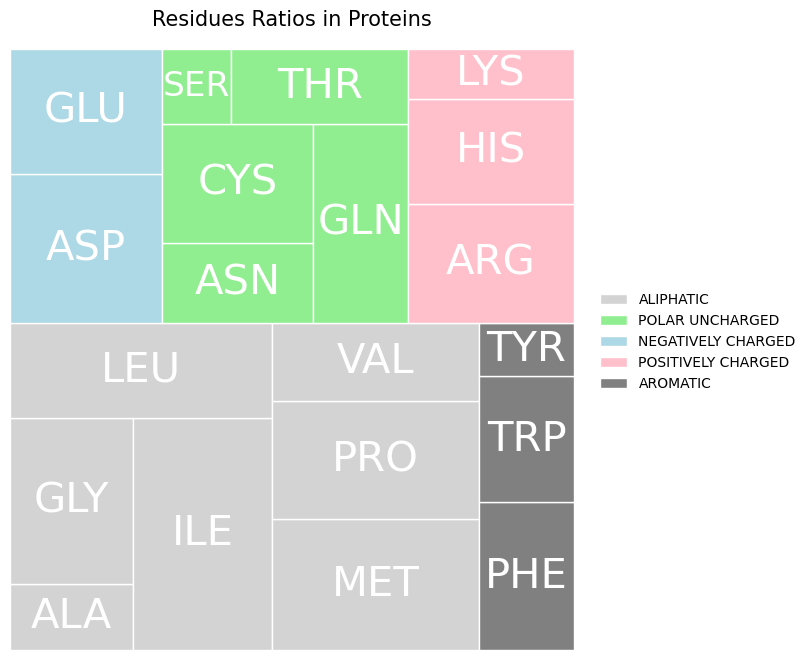

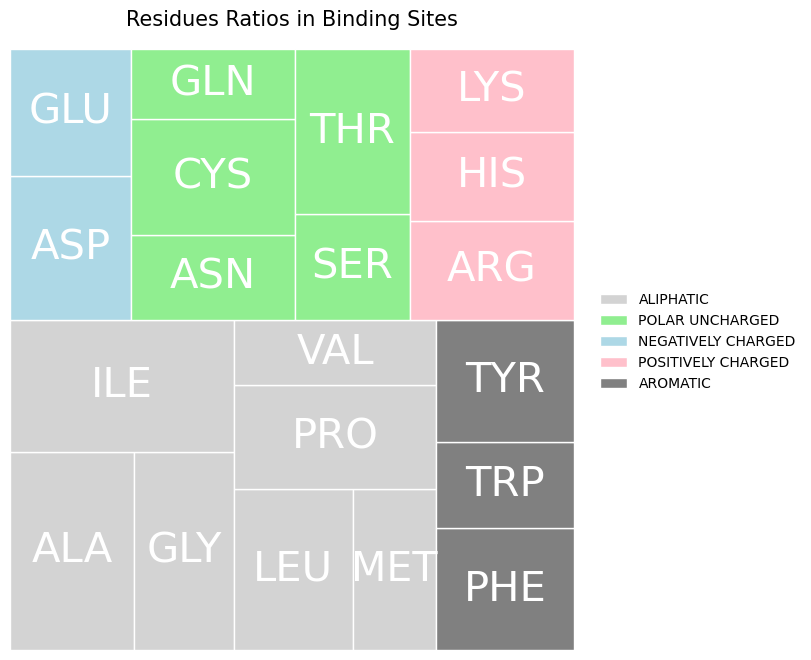

In [44]:
# Define the colormap
colormap={'ALIPHATIC': 'lightgrey', 'POLAR UNCHARGED': 'lightgreen', 'NEGATIVELY CHARGED': 'lightblue', 'POSITIVELY CHARGED': 'pink', 'AROMATIC': 'grey'}

# Pre-process the table: only for the whole protein
df_: pd.DataFrame = tables['Mol2ResCon']
df_ = df_.loc[df_['Category'].str.contains('Protein Structure Count'), ['Category', 'Mean']]
df_['RESIDUE'] = df_['Category'].str.removeprefix('Protein Structure Count ')
df_['TYPE'] = df_['RESIDUE'].map(u.SCPDB.RESIDUES_GROUPS)

u.construct_enclosure(
    df=df_,
    column_of_values='Mean', 
    column_of_annotations='RESIDUE',
    column_of_attribute='TYPE',
    colormap=colormap,
    title='Residues Ratios in Proteins',
    dim1=20,
    figsize=8,
    save='residues_ratios.pdf')

# Pre-process the table: only for the binding site
df_: pd.DataFrame = tables['Mol2ResCon']
df_ = df_.loc[df_['Category'].str.contains('Site Structure Count'), ['Category', 'Mean']]
df_['RESIDUE'] = df_['Category'].str.removeprefix('Site Structure Count ')
df_['TYPE'] = df_['RESIDUE'].map(u.SCPDB.RESIDUES_GROUPS)

u.construct_enclosure(
    df=df_,
    column_of_values='Mean', 
    column_of_annotations='RESIDUE',
    column_of_attribute='TYPE',
    colormap=colormap,
    title='Residues Ratios in Binding Sites',
    dim1=20,
    figsize=8,
    save='residues_ratios_in_site.pdf');


### 2.6.2 Configurations of Protein Chains

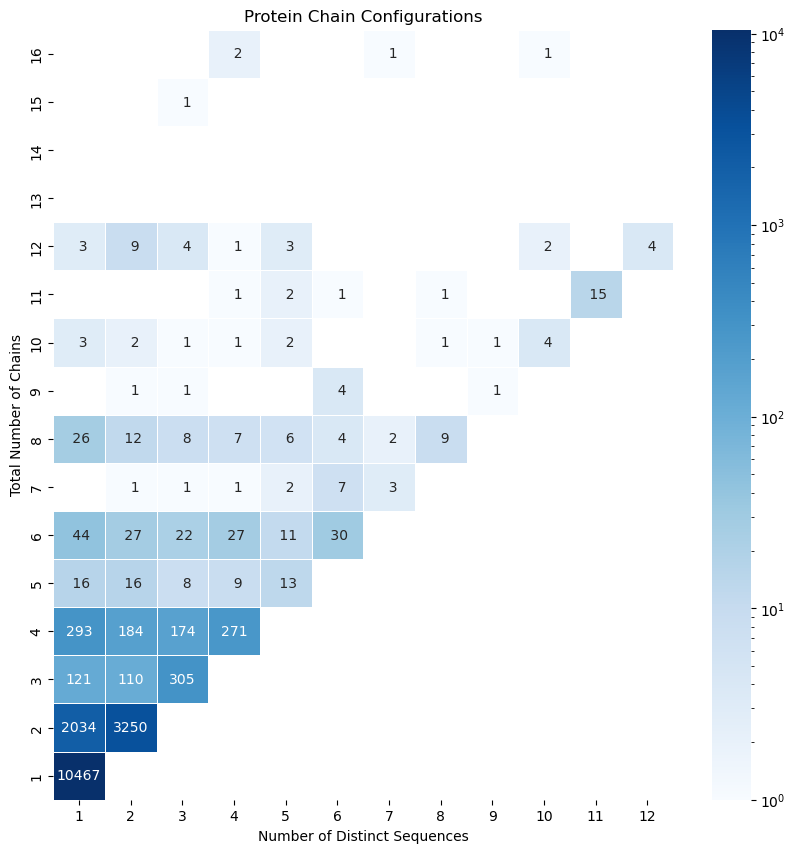

In [45]:
# Group df by chain metrics and count
chain_configs = df_complete[['mol2$Protein Number Of Chains',
                             'mol2$Protein Number Of Different Chains',
                             'basic$scPDB ID']].groupby(by=['mol2$Protein Number Of Chains',
                                                            'mol2$Protein Number Of Different Chains'], as_index=False).count()



# Create a mask for heatmap
mask = np.ones((17, 13))
for i in range(1, 17):
    for j in range(1, min(i+1, 13)):
        mask[i, j] = 0

# Store counts in matrix
m = np.zeros((17, 13))
for i, row in chain_configs.iterrows():
    m[row.iloc[0], row.iloc[1]] += row.iloc[2]

# Plot seaborn heatmap
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(m, ax=ax, norm=LogNorm(), cmap='Blues', linecolor='white', linewidths=0.5, mask=mask.astype(bool), annot=m, fmt='3g')
ax.set_xlabel('Number of Distinct Sequences')
ax.set_ylabel('Total Number of Chains')
ax.set_xlim((1, 13))
ax.set_ylim((1, 17))
ax.set_title('Protein Chain Configurations')
fig.savefig('chain_config.pdf')
plt.show()

### 2.6.3 SCOPe Classes

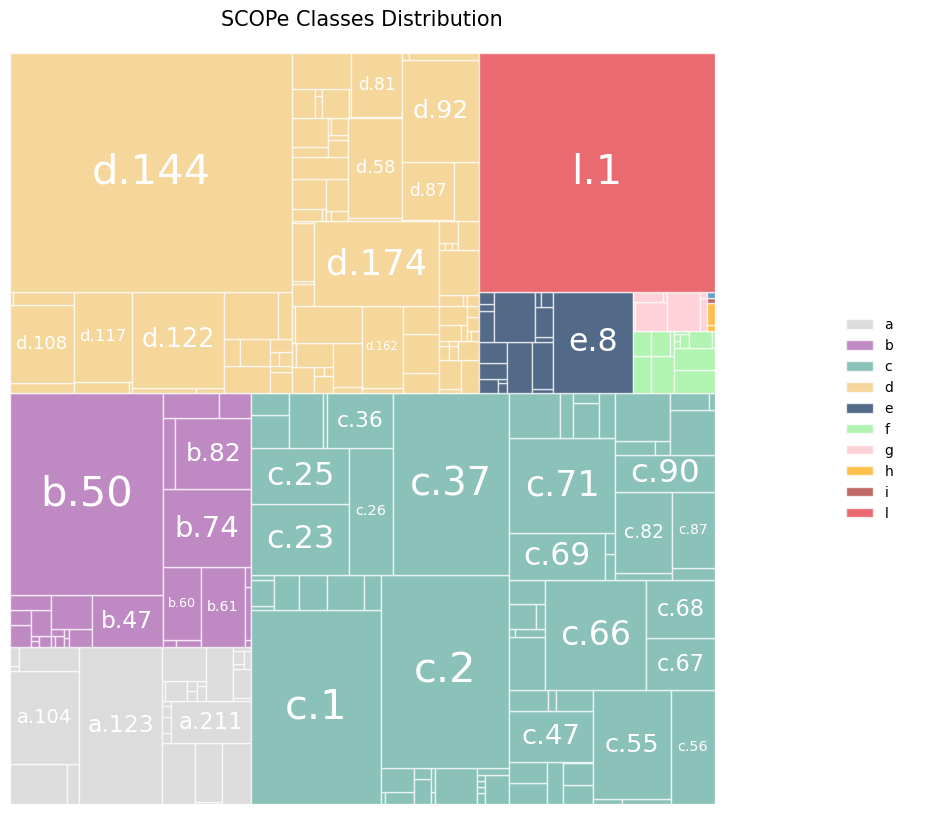

In [46]:
# Group SCOPe by class and subclass and count
scopes = df_complete[['html$SCOPe12 Dominant Chain', 'html$SCOPe Dominant Chain']]
scopes = scopes.loc[scopes['html$SCOPe12 Dominant Chain'].notna()]
scopes = scopes.groupby(by='html$SCOPe12 Dominant Chain', as_index=False).count()
scopes = scopes.rename(columns={'html$SCOPe Dominant Chain': 'Count'})
scopes['Class'] = scopes['html$SCOPe12 Dominant Chain'].map(lambda x: x.split('.')[0])

# Define color palette
colormap = {'a': '#cecece', 'b': '#a559aa', 'c': '#59a89c', 'd': '#f1c571', 'e': '#082a54',
            'f': 'lightgreen', 'g': 'pink', 'h': 'orange', 'i': 'brown', 'l': '#e02b35', }

u.construct_enclosure(
    df=scopes, 
    column_of_values='Count', 
    column_of_annotations='html$SCOPe12 Dominant Chain', 
    column_of_attribute='Class',
    figsize=10, 
    title='SCOPe Classes Distribution', 
    colormap=colormap, 
    alpha=0.7, 
    save='scopes.pdf');

### 2.6.4 EC Classes

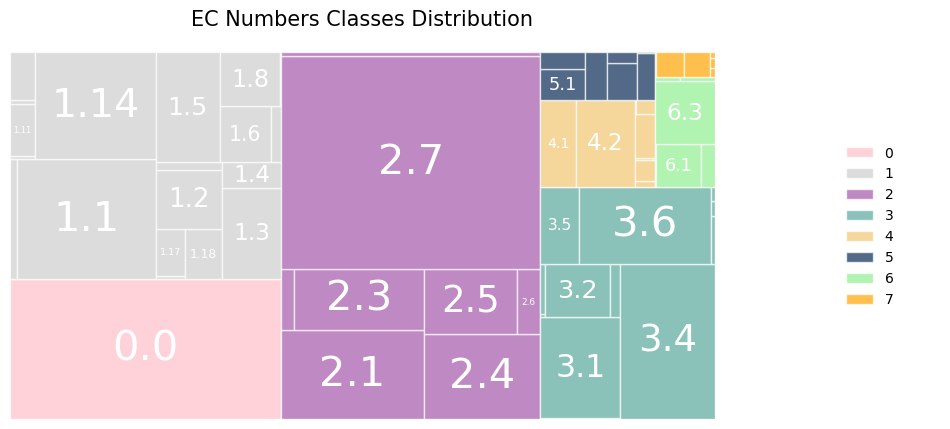

In [47]:
# Group ECs by class and subclass and count
ecs = df_complete[['basic$EC12', 'EC']]
ecs.loc[ecs['basic$EC12'].isna(), 'basic$EC12'] = '0.0'
ecs['basic$EC12'] = ecs['basic$EC12'].astype(str)
ecs = ecs.groupby(by='basic$EC12', as_index=False).count()
ecs = ecs.rename(columns={'EC': 'Count'})
ecs['Class'] = ecs['basic$EC12'].map(lambda x: x.split('.')[0])

# Define color palette
colormap = {'0': 'pink', '1': '#cecece', '2': '#a559aa', '3': '#59a89c', '4': '#f1c571', '5': '#082a54',
            '6': 'lightgreen', '7': 'orange'}

u.construct_enclosure(
    df=ecs, 
    column_of_values='Count',
    column_of_annotations='basic$EC12',
    column_of_attribute='Class',
    figsize=10,
    dim2=10,
    title='EC Numbers Classes Distribution',
    colormap=colormap,
    alpha=0.7,
    save='ECs.pdf');

### 2.6.5 Organisms and Kingdoms

<StringArray>
['Viruses', 'Eukaryota', 'Bacteriaeria', 'Archaea', 'Bacteria']
Length: 5, dtype: str

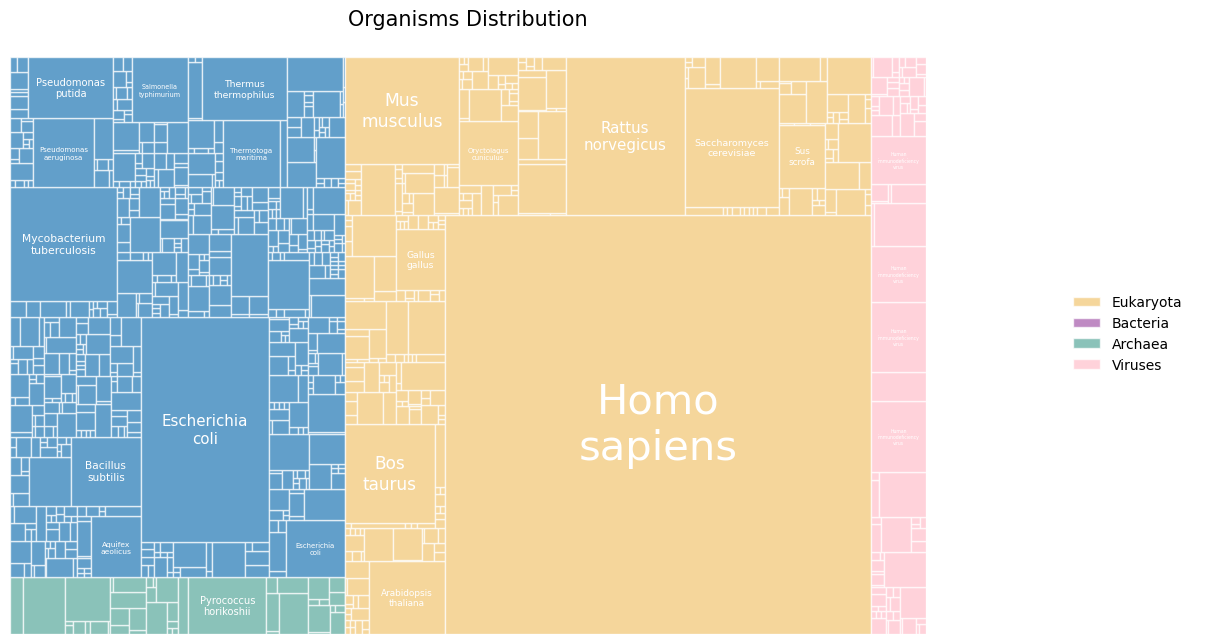

In [48]:
# Group ECs by class and subclass and count
orgs = df_complete[['uniprot$Organism', 'html$Reign']]
orgs = orgs[orgs['uniprot$Organism'].notna() & orgs['html$Reign'].notna()]
orgs['uniprot$Organism'] = orgs['uniprot$Organism'] + '@' + orgs['html$Reign']
orgs = orgs.groupby(by='uniprot$Organism', as_index=False).count()
orgs = orgs.rename(columns={'html$Reign': 'Count'})

orgs['Reign'] = orgs['uniprot$Organism'].map(lambda x: x.split('@')[1])
orgs['Reign'] = orgs['Reign'].str.replace('Bact', 'Bacteria')
orgs['Organism'] = orgs['uniprot$Organism'].map(lambda x: x.split('@')[0])

def clean_name(s):

    if 'virus' in s.lower():
        s = s.lower()
        s = s.split(' ')[:3]
        s = ' '.join(s).capitalize()

    else:
        s = s.lower()
        s = s.split(' ')[:2]
        s = ' '.join(s).capitalize()

    return s

orgs['Organism'] = orgs['Organism'].apply(clean_name)
display(orgs.Reign.unique())
colormap = {'Eukaryota': '#f1c571', 'Bacteria': '#a559aa', 'Archaea': '#59a89c', 'Viruses': 'pink'}

u.construct_enclosure(
    df=orgs, 
    column_of_values='Count',
    column_of_annotations='Organism',
    column_of_attribute='Reign',
    figsize=13,
    dim2=12,
    title='Organisms Distribution',
    colormap=colormap,
    alpha=0.7,
    save='organisms.pdf');

### 2.6.6 Protein Sizes

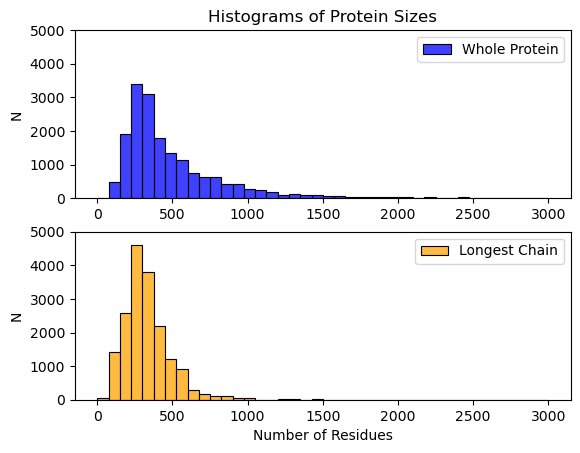

In [87]:
sizes = df_complete['mol2$Protein Number Of Residues'].values

fig, ax = plt.subplots(nrows=2, ncols=1)
bins = np.linspace(0, 3000, 1 + 2000//50, endpoint=True)
sns.histplot(df_complete, x='mol2$Protein Number Of Residues', bins=bins, label='Whole Protein', ax=ax[0], color='blue')
sns.histplot(df_complete, x='mol2$Protein Chain Number Of Residues', bins=bins, label='Longest Chain', ax=ax[1], color='orange')
ax[1].set_xlabel('Number of Residues')
ax[0].set_xlabel('')
ax[0].set_ylabel('N')
ax[1].set_ylabel('N')
ax[0].set_title('Histograms of Protein Sizes')
ax[0].legend()
ax[1].legend()
ax[0].set_ylim([0, 5000])
ax[1].set_ylim([0, 5000])
plt.show()